# Case iFood - 2. Modelagem: qual oferta enviar para cada cliente?

**Problema de decisão:** a cada campanha, escolher - para cada cliente - qual das 10 ofertas do
portfólio enviar, maximizando a chance de conversão.

**Abordagem:** um **modelo único de propensão** 'P(conversão | cliente, oferta)', em que as
características da oferta (tipo, desconto, gasto mínimo, duração, canais) entram como features
junto com o perfil e o comportamento histórico do cliente. Com um só modelo conseguimos pontuar
qualquer par cliente x oferta - a **política de recomendação** envia a oferta de maior propensão.

**Por que um modelo único (e não 10 modelos, um por oferta)?**
- compartilha aprendizado entre ofertas parecidas (ex.: os dois BOGOs de R$10);
- permite pontuar ofertas novas por interpolação dos atributos;
- é mais simples de treinar, validar e manter.

**Validação:** split e validação cruzada **agrupados por cliente** - nenhum cliente aparece em
treino e teste ao mesmo tempo (as linhas do mesmo cliente são correlacionadas; ignorar isso
inflaria as métricas).

In [1]:
import sys
from pathlib import Path

# permite importar src/ tanto rodando da raiz quanto de notebooks/
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import json
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.viz import SERIES, setup_style

setup_style()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RANDOM_STATE = 42  # semente única do notebook: split, CV e modelos reprodutíveis

# dataset unificado do notebook 1: 1 linha por oferta recebida, com o estado do
# cliente no momento do envio (features) e o desfecho da jornada (target 'converted')
df = pd.read_parquet(DATA_PROCESSED / "unified_dataset.parquet")
print(
    f"{df.shape[0]:,} ofertas recebidas | {df['account_id'].nunique():,} clientes que receberam oferta (de 17k cadastrados) | conversão média: {df['converted'].mean():.1%}"
)
df.head(3)

76,277 ofertas recebidas | 16,994 clientes que receberam oferta (de 17k cadastrados) | conversão média: 38.3%


,account_id,receipt_id,offer_id,t_received,hist_n_tx,hist_spend,hist_n_received,hist_n_viewed,hist_n_completed,hist_avg_ticket,...,window_n_tx,viewed,completed,converted,completed_blind,age,gender,credit_card_limit,membership_days,missing_profile
0,3fab840fa8cd489faf5b86ae7e49b340,18934,ae264e3637204a6fb9bb56bc8210ddfd,7.0,1,3.14,0,0,0,3.140000,...,1,1,0,0,0,36.0,M,33000.0,139,0
1,05f4d69f73024172a23a350e611166b4,1762,f19421c1d4aa40978ebb69ca19b0e20d,0.0,0,0.00,0,0,0,NaN,...,1,1,1,0,1,36.0,F,47000.0,190,0
2,d6f10a8cda5b41049c57f1a076227c14,64171,2298d6c36e964ae4a3e7e9706d1fb8c2,24.0,9,267.81,4,3,3,29.756667,...,2,1,1,1,0,68.0,F,98000.0,776,0


## 1. Análise exploratória do target

### 1.1 Conversão por oferta

O portfólio tem desempenhos muito distintos - e o "melhor" varia por cliente, que é justamente a
oportunidade que o modelo captura.

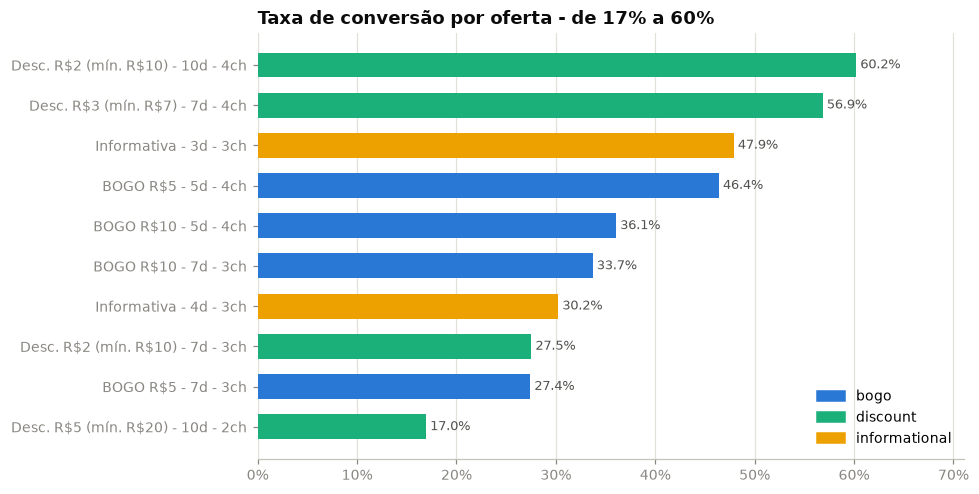

In [3]:
# Catálogo: as 10 ofertas únicas extraídas do dataset. Além da EDA, ele é
# reutilizado na seção 5 para pontuar TODAS as ofertas para cada cliente.
OFFER_COLS = [
    "offer_id",
    "offer_type",
    "min_value",
    "discount_value",
    "duration_days",
    "n_channels",
    "ch_web",
    "ch_email",
    "ch_mobile",
    "ch_social",
]
catalog = df[OFFER_COLS].drop_duplicates("offer_id").reset_index(drop=True)


# rótulo curto e legível para gráficos/tabelas (o id da oferta é um hash ilegível)
def offer_label(r):
    d = int(r["duration_days"])
    if r["offer_type"] == "bogo":
        return f"BOGO R${r['min_value']} - {d}d - {r['n_channels']}ch"
    if r["offer_type"] == "discount":
        return f"Desc. R${r['discount_value']} (mín. R${r['min_value']}) - {d}d - {r['n_channels']}ch"
    return f"Informativa - {d}d - {r['n_channels']}ch"


catalog["label"] = catalog.apply(offer_label, axis=1)
label_map = catalog.set_index("offer_id")["label"]

# conversão observada por oferta (base completa, antes de qualquer modelo)
por_oferta = (
    df.groupby("offer_id")
    .agg(
        enviadas=("converted", "size"),
        conversao=("converted", "mean"),
        visualizacao=("viewed", "mean"),
    )
    .join(label_map)
    .join(catalog.set_index("offer_id")["offer_type"])
    .sort_values("conversao")
)

# cor fixa por tipo de oferta (mesma associação em todos os gráficos do notebook)
type_color = {"bogo": SERIES[0], "discount": SERIES[1], "informational": SERIES[2]}
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh(
    por_oferta["label"],
    por_oferta["conversao"],
    color=por_oferta["offer_type"].map(type_color),
    height=0.62,
)
for yv, v in enumerate(por_oferta["conversao"]):
    ax.text(v + 0.004, yv, f"{v:.1%}", va="center", fontsize=8.5, color="#52514e")
ax.set_xlim(0, por_oferta["conversao"].max() * 1.18)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.grid(axis="y", visible=False)
ax.set_title(
    f"Taxa de conversão por oferta - de {por_oferta['conversao'].min():.0%} a {por_oferta['conversao'].max():.0%}"
)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in type_color.values()]
ax.legend(handles, type_color.keys(), loc="lower right")
plt.tight_layout()
plt.show()

### 1.2 Conversão por comportamento do cliente

O histórico recente do cliente (calculado **antes** de cada envio, no notebook 1 discrimina bem
a conversão - bom sinal para o modelo.

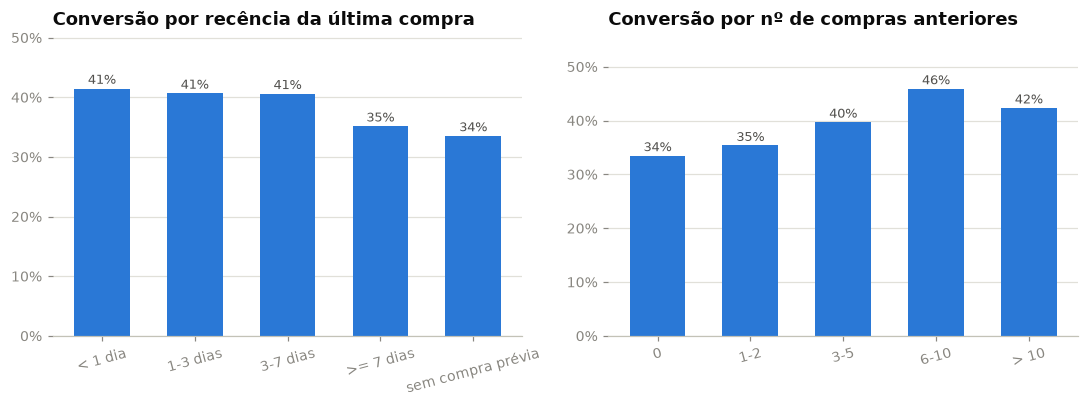

In [4]:
aux = df.copy()

# Faixas de negócio só para leitura da EDA (o modelo usa as variáveis contínuas).
# Recência NaN = cliente nunca comprou até o envio: vira categoria própria em vez
# de ser imputada - "nunca comprou" é um segmento real, com comportamento próprio.
aux["recencia"] = pd.cut(
    aux["days_since_last_tx"],
    bins=[0, 1, 3, 7, 31],
    right=False,
    labels=["< 1 dia", "1-3 dias", "3-7 dias", ">= 7 dias"],
).cat.add_categories("sem compra prévia")
aux.loc[aux["days_since_last_tx"].isna(), "recencia"] = "sem compra prévia"

aux["frequencia"] = pd.cut(
    aux["hist_n_tx"],
    bins=[0, 1, 3, 6, 11, 1000],
    right=False,
    labels=["0", "1-2", "3-5", "6-10", "> 10"],
)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, col, titulo in [
    (axes[0], "recencia", "Conversão por recência da última compra"),
    (axes[1], "frequencia", "Conversão por nº de compras anteriores"),
]:
    g = aux.groupby(col, observed=True)["converted"].mean()
    ax.bar(g.index.astype(str), g.values, color=SERIES[0], width=0.6)
    for xv, v in enumerate(g.values):
        ax.text(xv, v + 0.008, f"{v:.0%}", ha="center", fontsize=8.5, color="#52514e")
    ax.set_title(titulo)
    ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    ax.set_ylim(0, g.max() * 1.22)
    ax.grid(axis="x", visible=False)
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

## 2. Preparação para o modelo

**Features** (todas conhecidas no momento do envio - sem data leakage):
- **Oferta:** tipo, desconto, gasto mínimo, duração, canais;
- **Cliente:** idade, gênero, limite do cartão, tempo de casa, flag de cadastro incompleto;
- **Comportamento até o envio:** nº de compras, gasto acumulado, ticket médio, recência,
  ofertas recebidas/vistas/concluídas e taxas históricas de visualização/conclusão.

**O que fica de fora (e por quê):**
- **Target:** 'converted';
- **Desfechos** - só conhecidos *depois* do envio, logo seriam data leakage: 'viewed', 'completed',
  'completed_blind', 'reward_received', 't_first_view', 't_completion', 'window_spend',
  'window_n_tx'. São o que queremos prever/medir, não entrada do modelo;
- **Identificadores:** 'account_id', 'offer_id', 'receipt_id' - sem sinal generalizável (a oferta
  entra pelos seus **atributos**, não pelo id, o que permite pontuar ofertas novas);
- **Artefato do experimento:** o dia da onda ('t_received' / 't_expiry') - não se repete em produção.

Resultado: **23 features**, todas conhecíveis no instante do envio.

**Tratamento de valores ausentes:**
- 'gender' nulo vira categoria 'unknown' (o modelo aprende o segmento de cadastro incompleto);
- nulos numéricos (idade, recência etc.) são tratados nativamente pelo Gradient Boosting; na
  Regressão Logística, imputação por mediana + indicador de ausência.

In [5]:
# Features em dois grupos: categóricas (passam por encoding) e numéricas (uso direto)
CAT_FEATURES = ["offer_type", "gender"]
NUM_FEATURES = [
    "min_value",
    "discount_value",
    "duration_days",
    "n_channels",
    "ch_web",
    "ch_email",
    "ch_mobile",
    "ch_social",
    "age",
    "credit_card_limit",
    "membership_days",
    "missing_profile",
    "hist_n_tx",
    "hist_spend",
    "hist_avg_ticket",
    "days_since_last_tx",
    "hist_n_received",
    "hist_n_viewed",
    "hist_n_completed",
    "hist_view_rate",
    "hist_comp_rate",
]
FEATURES = CAT_FEATURES + NUM_FEATURES
TARGET = "converted"

model_df = df.copy()
# gender nulo é o segmento de cadastro incompleto (12,8% da base): vira categoria
# 'unknown' para o modelo aprender o padrão desse grupo, em vez de descartá-lo
model_df["gender"] = model_df["gender"].fillna("unknown")

X = model_df[FEATURES].copy()
# dtype 'category' ativa o tratamento nativo de categóricas do Gradient Boosting
# (sem one-hot manual); a regressão logística faz o encoding no próprio pipeline
for c in CAT_FEATURES:
    X[c] = X[c].astype("category")
y = model_df[TARGET].astype(int)
# grupos para o split: todas as linhas de um mesmo cliente ficam do mesmo lado
groups = model_df["account_id"]

print(f"{X.shape[1]} features | target: {y.mean():.1%} positivo")

23 features | target: 38.3% positivo


In [6]:
from sklearn.model_selection import GroupShuffleSplit

# Split por CLIENTE, não por linha: o mesmo cliente aparece em até 6 envios e suas
# linhas são correlacionadas - um split aleatório por linha deixaria "meio cliente"
# em cada lado e inflaria as métricas de teste.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, y_train, g_train = X.iloc[train_idx], y.iloc[train_idx], groups.iloc[train_idx]
X_test, y_test, g_test = X.iloc[test_idx], y.iloc[test_idx], groups.iloc[test_idx]

# garantia de zero interseção de clientes entre treino e teste
assert set(g_train) & set(g_test) == set(), "cliente presente em treino e teste"
print(
    f"treino: {len(X_train):,} linhas / {g_train.nunique():,} clientes (conv. {y_train.mean():.1%})"
)
print(
    f"teste:  {len(X_test):,} linhas / {g_test.nunique():,} clientes (conv. {y_test.mean():.1%})"
)

treino: 61,062 linhas / 13,595 clientes (conv. 38.2%)
teste:  15,215 linhas / 3,399 clientes (conv. 38.6%)


## 3. Treino e seleção do modelo

Três candidatos, comparados com **validação cruzada 5-fold agrupada por cliente** no treino:

| Modelo | Papel |
|---|---|
| 'DummyClassifier' | piso de referência (prevalência) |
| Regressão Logística | referência linear, interpretável |
| 'HistGradientBoostingClassifier' | não-linear, lida nativamente com nulos e categóricas; padrão forte para dados tabulares |


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Regressão logística: referência linear. O pré-processamento vive DENTRO do
# pipeline, então imputação e escala são aprendidas apenas no treino de cada fold
# da validação cruzada (sem vazamento do fold de validação).
lr = Pipeline(
    [
        (
            "prep",
            ColumnTransformer(
                [
                    (
                        "num",
                        Pipeline(
                            [
                                # imputa mediana nas numéricas; add_indicator=True cria a flag
                                # "estava ausente" - preserva o sinal de "nunca comprou"
                                (
                                    "imp",
                                    SimpleImputer(
                                        strategy="median", add_indicator=True
                                    ),
                                ),
                                # padroniza para média 0 / desvio 1 (necessário em modelo linear)
                                ("sc", StandardScaler()),
                            ]
                        ),
                        NUM_FEATURES,
                    ),
                    # codifica categóricas em dummies 0/1; handle_unknown="ignore" evita
                    # erro se aparecer categoria que não existia no treino
                    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES),
                ]
            ),
        ),
        # max_iter alto garante convergência do otimizador
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]
)

hgb = HistGradientBoostingClassifier(
    learning_rate=0.06,  # taxa de aprendizado menor: passos curtos, menos overfitting
    max_iter=300,  # mais árvores para compensar a taxa de aprendizado menor
    min_samples_leaf=40,  # amostra mínima por folha maior: suaviza e regulariza
    l2_regularization=1.0,  # regularização L2 nos valores das folhas
    categorical_features="from_dtype",  # colunas dtype "category" tratadas nativamente
    early_stopping=False,  # a validação interna do early stopping não respeita os grupos de cliente
    random_state=RANDOM_STATE,  # semente para reprodutibilidade
)

# Dummy = piso de referência: qualquer modelo útil precisa superá-lo com folga
models = {
    "Baseline (prevalência)": DummyClassifier(strategy="prior"),
    "Regressão Logística": lr,
    "Gradient Boosting": hgb,
}

# CV 5-fold agrupada por cliente: mesma regra anti-vazamento do split de teste.
# Métricas: ROC-AUC (qualidade do ranking) e PR-AUC (desempenho na classe positiva).
cv = GroupKFold(n_splits=5)
linhas = []
for nome, m in models.items():
    res = cross_validate(
        m,
        X_train,
        y_train,
        groups=g_train,
        cv=cv,
        scoring=["roc_auc", "average_precision"],
    )
    linhas.append(
        {
            "modelo": nome,
            "ROC-AUC (cv)": f"{res['test_roc_auc'].mean():.3f} +- {res['test_roc_auc'].std():.3f}",
            "PR-AUC (cv)": f"{res['test_average_precision'].mean():.3f} +- {res['test_average_precision'].std():.3f}",
        }
    )
pd.DataFrame(linhas)

,modelo,ROC-AUC (cv),PR-AUC (cv)
0,Baseline (prevalência),0.500 +- 0.000,0.382 +- 0.006
1,Regressão Logística,0.740 +- 0.006,0.614 +- 0.007
2,Gradient Boosting,0.803 +- 0.006,0.694 +- 0.006


O Gradient Boosting supera a referência linear com folga e estabilidade entre folds - será o
modelo final. Ajustes finos de hiperparâmetros trariam ganho marginal frente ao custo; mantemos
uma configuração regularizada e simples.

## 4. Avaliação no conjunto de teste (clientes nunca vistos)

In [8]:
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

# ajuste final no treino completo; o conjunto de teste é usado UMA única vez, aqui
lr.fit(X_train, y_train)
hgb.fit(X_train, y_train)

p_lr = lr.predict_proba(X_test)[:, 1]
p_hgb = hgb.predict_proba(X_test)[:, 1]

# ROC-AUC: o modelo ordena bem? | PR-AUC: precisão na classe positiva |
# Brier: as probabilidades são confiáveis? (menor = melhor; importa porque a
# política da seção 5 usa as probabilidades, não só o ranking)
avaliacao = pd.DataFrame(
    [
        {
            "modelo": nome,
            "ROC-AUC": roc_auc_score(y_test, p),
            "PR-AUC": average_precision_score(y_test, p),
            "Brier": brier_score_loss(y_test, p),
        }
        for nome, p in [("Regressão Logística", p_lr), ("Gradient Boosting", p_hgb)]
    ]
).round(4)
avaliacao

,modelo,ROC-AUC,PR-AUC,Brier
0,Regressão Logística,0.7398,0.6186,0.1982
1,Gradient Boosting,0.8012,0.6997,0.1754


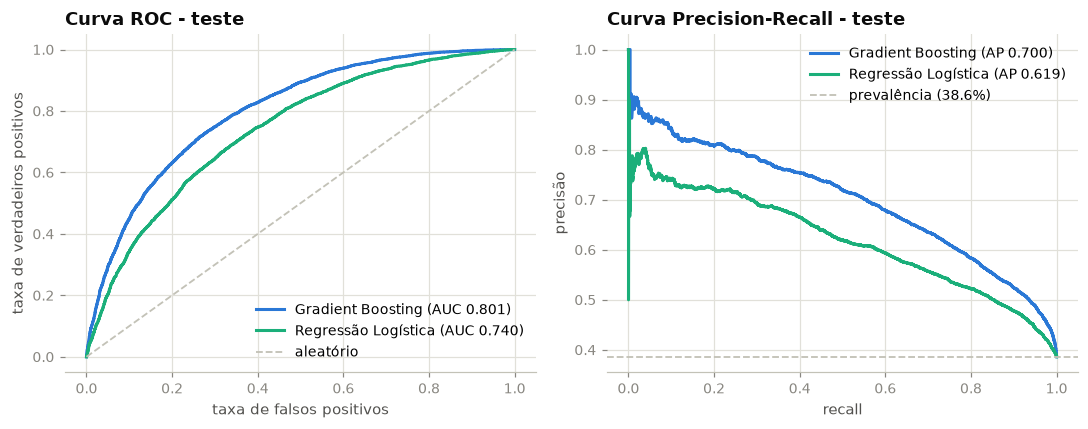

In [9]:
# ROC: diagonal tracejada = classificador aleatório | PR: linha tracejada =
# prevalência, o piso de precisão de quem prevê positivo para todo mundo
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for nome, p, cor in [
    ("Gradient Boosting", p_hgb, SERIES[0]),
    ("Regressão Logística", p_lr, SERIES[1]),
]:
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(
        fpr,
        tpr,
        color=cor,
        linewidth=2,
        label=f"{nome} (AUC {roc_auc_score(y_test, p):.3f})",
    )
axes[0].plot(
    [0, 1], [0, 1], color="#c3c2b7", linestyle="--", linewidth=1.2, label="aleatório"
)
axes[0].set_title("Curva ROC - teste")
axes[0].set_xlabel("taxa de falsos positivos")
axes[0].set_ylabel("taxa de verdadeiros positivos")
axes[0].legend(loc="lower right")

for nome, p, cor in [
    ("Gradient Boosting", p_hgb, SERIES[0]),
    ("Regressão Logística", p_lr, SERIES[1]),
]:
    prec, rec, _ = precision_recall_curve(y_test, p)
    axes[1].plot(
        rec,
        prec,
        color=cor,
        linewidth=2,
        label=f"{nome} (AP {average_precision_score(y_test, p):.3f})",
    )
axes[1].axhline(
    y_test.mean(),
    color="#c3c2b7",
    linestyle="--",
    linewidth=1.2,
    label=f"prevalência ({y_test.mean():.1%})",
)
axes[1].set_title("Curva Precision-Recall - teste")
axes[1].set_xlabel("recall")
axes[1].set_ylabel("precisão")
axes[1].legend(loc="upper right")
plt.tight_layout()
plt.show()

### 4.1 Calibração e lift

Para uma política de decisão importa que a probabilidade prevista seja **confiável** (calibração)
e que o ranking **concentre conversões no topo** (lift).

**Nota metodológica:** o conjunto de teste é usado **apenas para avaliar** (discriminação e
calibração) - nada é ajustado nele; a seleção de modelo acontece na validação cruzada do treino.
Como as probabilidades já saem bem calibradas (curva colada na diagonal, Brier 0,175), não é
necessário calibrador pós-hoc. Se não fosse o caso, ajustaríamos um calibrador (Platt/isotônico)
em uma partição de validação do treino - nunca no teste, que permaneceria intocado para a
avaliação final.

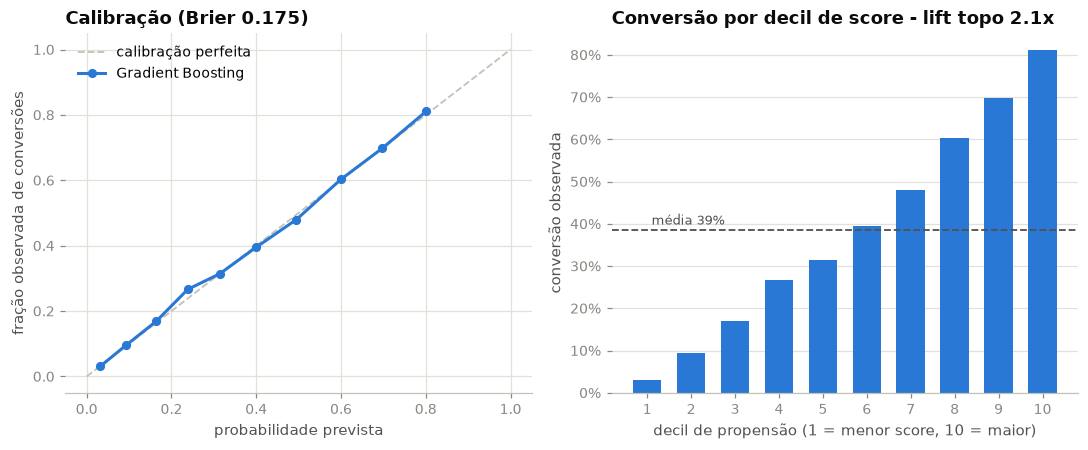

In [10]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

# Calibração: strategy="quantile" cria 10 bins com o MESMO nº de observações;
# curva colada na diagonal = probabilidade prevista ~ fração real de conversões,
# pré-requisito para usar o score em contas de negócio (projeções da seção 6)
frac_pos, mean_pred = calibration_curve(y_test, p_hgb, n_bins=10, strategy="quantile")
axes[0].plot(
    [0, 1],
    [0, 1],
    color="#c3c2b7",
    linestyle="--",
    linewidth=1.2,
    label="calibração perfeita",
)
axes[0].plot(
    mean_pred,
    frac_pos,
    marker="o",
    markersize=5,
    color=SERIES[0],
    linewidth=2,
    label="Gradient Boosting",
)
axes[0].set_title(f"Calibração (Brier {brier_score_loss(y_test, p_hgb):.3f})")
axes[0].set_xlabel("probabilidade prevista")
axes[0].set_ylabel("fração observada de conversões")
axes[0].legend(loc="upper left")

# Lift por decil: leitura de negócio do ranking - quanto o topo dos scores
# concentra conversões em relação à média (base para priorizar envios)
dec = pd.qcut(p_hgb, 10, labels=False, duplicates="drop") + 1
lift_df = (
    pd.DataFrame({"decil": dec, "y": y_test.to_numpy()}).groupby("decil")["y"].mean()
)
axes[1].bar(
    lift_df.index.astype(int).astype(str), lift_df.values, color=SERIES[0], width=0.65
)
axes[1].axhline(y_test.mean(), color="#52514e", linestyle="--", linewidth=1.2)
axes[1].text(
    0.1,
    y_test.mean() + 0.012,
    f"média {y_test.mean():.0%}",
    fontsize=8.5,
    color="#52514e",
)
axes[1].set_title(
    f"Conversão por decil de score - lift topo {lift_df.iloc[-1] / y_test.mean():.1f}x"
)
axes[1].set_xlabel("decil de propensão (1 = menor score, 10 = maior)")
axes[1].set_ylabel("conversão observada")
axes[1].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
axes[1].grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

**Como ler o lift do topo (2,1x):** ordenando os envios pela propensão prevista e agrupando em
10 decis, o decil de maior score converte **~2,1X a média** (≈81% vs 38,6%). É a tradução prática
do ranking - direcionar os envios aos clientes mais propensos rende mais que disparar na média, o
argumento direto para priorizar.

Assim como o AUC, mede **propensão** (ordenação), não
**incrementalidade**: quanto do ganho é *causado* pela oferta exige uplift/teste A/B (seção 8).

In [11]:
# Desempenho por tipo de oferta: verifica se o modelo ordena bem DENTRO de cada
# tipo (e não só separa tipos entre si) - requisito para a política da seção 5,
# que compara ofertas do mesmo tipo entre si
por_tipo = (
    pd.DataFrame(
        {
            "offer_type": model_df.iloc[test_idx]["offer_type"].to_numpy(),
            "y": y_test.to_numpy(),
            "p": p_hgb,
        }
    )
    .groupby("offer_type")
    .apply(
        lambda g: pd.Series(
            {
                "n": len(g),
                "conversao": g["y"].mean(),
                "ROC-AUC": roc_auc_score(g["y"], g["p"]),
            }
        ),
        include_groups=False,
    )
    .round(3)
)
por_tipo

,n,conversao,ROC-AUC
offer_type,,,
bogo,6107.0,0.354,0.802
discount,6098.0,0.414,0.828
informational,3010.0,0.396,0.727


### 4.2 O que o modelo usa para decidir

Importância por permutação no teste (queda de ROC-AUC ao embaralhar cada feature).

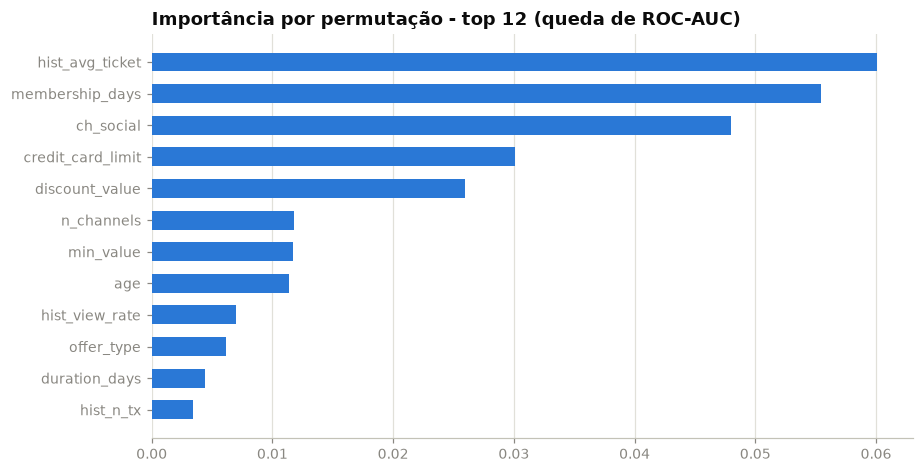

In [12]:
from sklearn.inspection import permutation_importance

# Importância por permutação, medida no TESTE: embaralha uma feature por vez e
# mede a queda de ROC-AUC. É agnóstica ao modelo e serve de checagem de sanidade:
# uma feature "importante demais" seria indício de vazamento
imp = permutation_importance(
    hgb, X_test, y_test, scoring="roc_auc", n_repeats=5, random_state=RANDOM_STATE
)
imp_df = pd.Series(imp.importances_mean, index=FEATURES).sort_values().tail(12)
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.barh(imp_df.index, imp_df.values, color=SERIES[0], height=0.6)
ax.set_title("Importância por permutação - top 12 (queda de ROC-AUC)")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

As features mais importantes são o **gasto histórico** do cliente ('hist_avg_ticket'), o **tempo
de casa** ('membership_days') e o **canal social** da oferta ('ch_social'), seguidos de limite de
cartão e desconto. O sinal se distribui entre os três grupos - histórico, perfil do cliente e
atributos da oferta e, no topo, **não há nenhuma feature de desfecho/vazamento**, que é a
checagem de sanidade esperada. (Taxa de conclusão e recência aparecem baixas em parte por
correlação com features como gasto e frequência.)

## 5. Política de recomendação: a melhor oferta para cada cliente

Para cada cliente do teste, pontuamos as **10 ofertas** do portfólio com o estado do cliente no
momento do envio e recomendamos a de maior propensão.

In [13]:
# Estado do cliente no momento do envio: apenas colunas de cliente/histórico -
# nada de oferta (será variada no grid) nem de desfecho (seria vazamento)
CUST_COLS = [
    "receipt_id",
    "age",
    "gender",
    "credit_card_limit",
    "membership_days",
    "missing_profile",
    "hist_n_tx",
    "hist_spend",
    "hist_avg_ticket",
    "days_since_last_tx",
    "hist_n_received",
    "hist_n_viewed",
    "hist_n_completed",
    "hist_view_rate",
    "hist_comp_rate",
]

# junto com o estado, guardamos a oferta REALMENTE enviada e o desfecho observado
test_states = model_df.iloc[test_idx][
    CUST_COLS + ["offer_id", "converted"]
].reset_index(drop=True)

# produto cartesiano: cada estado de cliente x as 10 ofertas do catálogo -
# o MESMO modelo pontua qualquer par cliente-oferta
grid = test_states[CUST_COLS].merge(catalog.drop(columns="label"), how="cross")
Xg = grid[FEATURES].copy()
# re-cast para category: o predict exige os mesmos dtypes usados no treino
for c in CAT_FEATURES:
    Xg[c] = Xg[c].astype("category")
grid["p_convert"] = hgb.predict_proba(Xg)[:, 1]

# recomendação = oferta de maior propensão para cada recebimento (idxmax por grupo)
best = grid.loc[
    grid.groupby("receipt_id")["p_convert"].idxmax(),
    ["receipt_id", "offer_id", "p_convert"],
]
best = best.rename(columns={"offer_id": "recommended_offer", "p_convert": "p_best"})

# match = a oferta sorteada no experimento coincidiu com a recomendada. Como o
# envio foi aleatório entre ~10 ofertas, esperamos match em ~10% dos envios -
# esse subgrupo é a base do quase-experimento da seção 6
eval_df = test_states.merge(best, on="receipt_id")
eval_df["match"] = eval_df["offer_id"] == eval_df["recommended_offer"]
print(f"{len(grid):,} pares cliente-estado x oferta pontuados")
print(
    f"envios do teste que coincidiram com a recomendação: {eval_df['match'].mean():.1%}"
)

152,150 pares cliente-estado x oferta pontuados
envios do teste que coincidiram com a recomendação: 9.9%


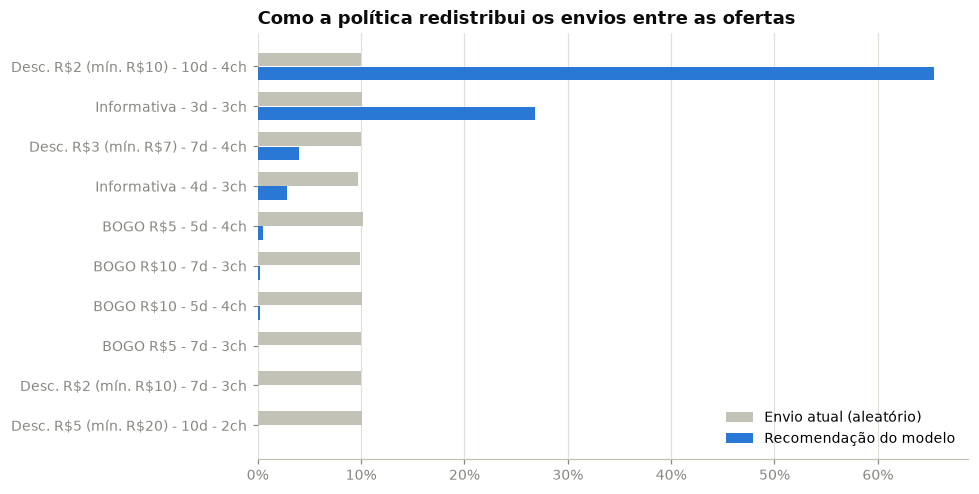

In [14]:
# envio atual ~uniforme (cada oferta com ~10% dos envios) vs concentração da política
dist = pd.DataFrame(
    {
        "Envio atual (aleatório)": eval_df["offer_id"].value_counts(normalize=True),
        "Recomendação do modelo": eval_df["recommended_offer"].value_counts(
            normalize=True
        ),
    }
).fillna(0)
dist.index = dist.index.map(label_map)
dist = dist.sort_values("Recomendação do modelo")

yv = np.arange(len(dist))
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh(
    yv + 0.18,
    dist["Envio atual (aleatório)"],
    height=0.34,
    color="#c3c2b7",
    label="Envio atual (aleatório)",
)
ax.barh(
    yv - 0.18,
    dist["Recomendação do modelo"],
    height=0.34,
    color=SERIES[0],
    label="Recomendação do modelo",
)
ax.set_yticks(yv, dist.index)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.grid(axis="y", visible=False)
ax.set_title("Como a política redistribui os envios entre as ofertas")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

A política concentra recomendações nas ofertas de maior resposta (desconto de longa duração e
informativas de baixo custo) - esperado quando o objetivo é só conversão. Em produção, restrições
de verba, margem e diversidade de portfólio entrariam como *guardrails* da política (ver seção 8).

## 6. Impacto estimado no negócio

Como no experimento as ofertas foram distribuídas de forma **aleatória**, os envios que por acaso
coincidiram com a recomendação do modelo formam um grupo comparável aos demais - um
**quase-experimento natural**: comparamos a conversão observada dos envios "certos" (iguais à
recomendação) com a dos demais envios.

conversão | envio = recomendado : 66.0%  (IC95% 63.6%-68.3%, n=1,513)
conversão | envio != recomendado : 35.6%  (IC95% 34.8%-36.4%, n=13,702)
conversão média (política atual): 38.6%
benchmark melhor oferta única p/ todos (Desc. R$2 (mín. R$10) - 10d - 4ch): 62.8%
uplift vs política atual: +27.3 p.p. (+71%)
uplift vs melhor oferta única: +3.2 p.p.


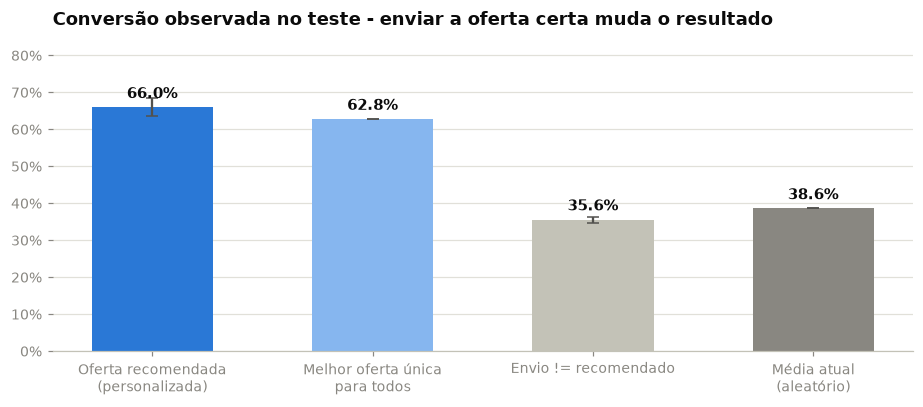

In [15]:
# intervalo de confiança normal (95%) para proporções
def prop_ci(p, n, z=1.96):
    se = np.sqrt(p * (1 - p) / n)
    return p - z * se, p + z * se


# Como a atribuição das ofertas no experimento foi ALEATÓRIA, o grupo
# "envio = recomendado" é comparável aos demais: a diferença de conversão pode ser
# lida como efeito da política, e não como diferença de perfil entre os grupos.
conv_match = eval_df.loc[eval_df["match"], "converted"].mean()
conv_mismatch = eval_df.loc[~eval_df["match"], "converted"].mean()
conv_overall = eval_df["converted"].mean()
n_match = int(eval_df["match"].sum())
n_mismatch = int((~eval_df["match"]).sum())

ci_match = prop_ci(conv_match, n_match)
ci_mismatch = prop_ci(conv_mismatch, n_mismatch)

uplift_pp = (conv_match - conv_overall) * 100
uplift_rel = conv_match / conv_overall - 1

# benchmark exigente: e se enviássemos a MESMA melhor oferta para todos?
# (separa o ganho de personalização do ganho de escolher a melhor oferta média)
conv_por_oferta = eval_df.groupby("offer_id")["converted"].mean()
best_single_id = conv_por_oferta.idxmax()
conv_best_single = float(conv_por_oferta.max())

print(f"conversão | envio = recomendado : {conv_match:.1%}  (IC95% {ci_match[0]:.1%}-{ci_match[1]:.1%}, n={n_match:,})")
print(f"conversão | envio != recomendado : {conv_mismatch:.1%}  (IC95% {ci_mismatch[0]:.1%}-{ci_mismatch[1]:.1%}, n={n_mismatch:,})")
print(f"conversão média (política atual): {conv_overall:.1%}")
print(f"benchmark melhor oferta única p/ todos ({label_map[best_single_id]}): {conv_best_single:.1%}")
print(f"uplift vs política atual: +{uplift_pp:.1f} p.p. ({uplift_rel:+.0%})")
print(f"uplift vs melhor oferta única: +{(conv_match - conv_best_single) * 100:.1f} p.p.")

fig, ax = plt.subplots(figsize=(8.5, 3.8))
barras = [
    "Oferta recomendada\n(personalizada)",
    "Melhor oferta única\npara todos",
    "Envio != recomendado",
    "Média atual\n(aleatório)",
]
vals = [conv_match, conv_best_single, conv_mismatch, conv_overall]
cores = [SERIES[0], "#86b6ef", "#c3c2b7", "#898781"]
# barras de erro = IC95%; só os grupos observados diretamente têm IC
err = [
    (conv_match - ci_match[0], ci_match[1] - conv_match),
    (0, 0),
    (conv_mismatch - ci_mismatch[0], ci_mismatch[1] - conv_mismatch),
    (0, 0),
]
ax.bar(
    barras,
    vals,
    color=cores,
    width=0.55,
    yerr=np.array(err).T,
    ecolor="#52514e",
    capsize=4,
)
for xv, v in enumerate(vals):
    ax.text(xv, v + 0.025, f"{v:.1%}", ha="center", fontweight="bold", color="#0b0b0b")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.set_ylim(0, max(vals) * 1.3)
ax.grid(axis="x", visible=False)
ax.set_title("Conversão observada no teste - enviar a oferta certa muda o resultado")
plt.tight_layout()
plt.show()

In [16]:
# Leitura complementar: conversão esperada se TODOS os envios seguissem a
# recomendação. É autoavaliação do modelo (depende da calibração) - por isso o
# quase-experimento acima é a evidência principal e esta projeção, corroboração.
policy_expected = eval_df["p_best"].mean()
print(
    f"conversão esperada com 100% dos envios recomendados (modelo): {policy_expected:.1%}"
)

# desperdício atual: descontos concedidos sem influência do envio
# (oferta concluída sem ter sido vista - 'completed_blind' do notebook 1)
blind = df[df["completed_blind"] == 1]
total_reward = df["reward_received"].sum()
blind_reward = blind["reward_received"].sum()
print(f"descontos pagos no teste (30 dias): R$ {total_reward:,.0f}")
print(
    f"pagos sem o cliente ter visto a oferta: R$ {blind_reward:,.0f} ({blind_reward / total_reward:.0%})"
)

# referência de valor por conversão para as projeções da apresentação
ticket_convertido = df.loc[df["converted"] == 1, "window_spend"].median()
print(
    f"gasto mediano do cliente na janela de uma oferta convertida: R$ {ticket_convertido:,.2f}"
)

conversão esperada com 100% dos envios recomendados (modelo): 63.1%
descontos pagos no teste (30 dias): R$ 162,426
pagos sem o cliente ter visto a oferta: R$ 48,216 (30%)
gasto mediano do cliente na janela de uma oferta convertida: R$ 31.98


## 7. Exportação dos resultados

In [17]:
# persiste o modelo treinado para reuso (scoring fora deste notebook)
joblib.dump(hgb, DATA_PROCESSED / "propensity_model.joblib")

funil_tipo = (
    df.groupby("offer_type")
    .agg(
        enviadas=("converted", "size"),
        taxa_view=("viewed", "mean"),
        taxa_conversao=("converted", "mean"),
        taxa_cega=("completed_blind", "mean"),
    )
    .round(4)
)

# consolida os números-chave do case em um único JSON - fonte dos valores usados
# na apresentação para stakeholders (presentation/apresentacao.html)
results = {
    "n_receipts": int(len(df)),
    "n_customers": int(df["account_id"].nunique()),
    "test_receipts": int(len(test_idx)),
    "test_customers": int(g_test.nunique()),
    "auc_hgb": round(float(roc_auc_score(y_test, p_hgb)), 4),
    "ap_hgb": round(float(average_precision_score(y_test, p_hgb)), 4),
    "auc_lr": round(float(roc_auc_score(y_test, p_lr)), 4),
    "brier_hgb": round(float(brier_score_loss(y_test, p_hgb)), 4),
    "lift_top_decile": round(float(lift_df.iloc[-1] / y_test.mean()), 2),
    "conv_overall_test": round(float(conv_overall), 4),
    "conv_match": round(float(conv_match), 4),
    "conv_mismatch": round(float(conv_mismatch), 4),
    "ci_match": [round(float(v), 4) for v in ci_match],
    "n_match": n_match,
    "uplift_pp": round(float(uplift_pp), 2),
    "uplift_rel": round(float(uplift_rel), 4),
    "conv_best_single_offer": round(conv_best_single, 4),
    "best_single_offer_label": str(label_map[best_single_id]),
    "policy_expected_conv": round(float(policy_expected), 4),
    "total_reward": round(float(total_reward), 2),
    "blind_reward": round(float(blind_reward), 2),
    "median_window_spend_converted": round(float(ticket_convertido), 2),
    "funnel_by_type": funil_tipo.reset_index().to_dict(orient="records"),
    "reco_share": {
        label_map[k]: round(float(v), 4)
        for k, v in eval_df["recommended_offer"].value_counts(normalize=True).items()
    },
}
with open(DATA_PROCESSED / "model_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print("salvos: propensity_model.joblib, model_results.json")
results

salvos: propensity_model.joblib, model_results.json


{'n_receipts': 76277,
 'n_customers': 16994,
 'test_receipts': 15215,
 'test_customers': 3399,
 'auc_hgb': 0.8012,
 'ap_hgb': 0.6997,
 'auc_lr': 0.7398,
 'brier_hgb': 0.1754,
 'lift_top_decile': 2.1,
 'conv_overall_test': 0.3861,
 'conv_match': 0.6596,
 'conv_mismatch': 0.3559,
 'ci_match': [0.6357, 0.6835],
 'n_match': 1513,
 'uplift_pp': 27.35,
 'uplift_rel': 0.7083,
 'conv_best_single_offer': 0.6279,
 'best_single_offer_label': 'Desc. R$2 (mín. R$10) - 10d - 4ch',
 'policy_expected_conv': 0.631,
 'total_reward': 162426.0,
 'blind_reward': 48216.0,
 'median_window_spend_converted': 31.98,
 'funnel_by_type': [{'offer_type': 'bogo',
   'enviadas': 30499,
   'taxa_view': 0.8279,
   'taxa_conversao': 0.3587,
   'taxa_cega': 0.1495},
  {'offer_type': 'discount',
   'enviadas': 30543,
   'taxa_view': 0.6997,
   'taxa_conversao': 0.4036,
   'taxa_cega': 0.1727},
  {'offer_type': 'informational',
   'enviadas': 15235,
   'taxa_view': 0.6529,
   'taxa_conversao': 0.3908,
   'taxa_cega': 0.0}]

## 8. Conclusões, limitações e próximos passos

**Conclusões**
- Um modelo único de propensão cliente x oferta atinge boa discriminação e calibração em clientes
  nunca vistos, usando apenas informação disponível no momento do envio.
- No quase-experimento (envio aleatório do teste), os envios que coincidiram com a recomendação
  do modelo converteram significativamente mais do que a política atual - com intervalo de
  confiança que não se sobrepõe à média - e acima até do benchmark exigente de "melhor oferta
  única para todos": o ganho vem da **personalização**, não só da escolha de uma boa oferta média.
- Além do ganho de conversão, o diagnóstico do funil revelou desperdício relevante: parte dos
  descontos é paga sem o cliente sequer ver a oferta.

**Limitações (e como endereçá-las)**
1. **Propensão != incrementalidade**: o modelo prevê quem converte se receber a oferta, não o
   efeito causal do envio. Evolução natural: *uplift modeling* (exigiria grupo controle sem
   oferta por período).
2. A estimativa de impacto é quase-experimental; a validação definitiva é um **teste A/B**
   (política atual vs política do modelo), que é a recomendação de rollout.
3. A política maximiza conversão; com dados de margem por pedido, o mesmo score vira uma
   política de **valor esperado** (probabilidade x margem - custo do desconto) sem retreinar nada.
4. Cobertura: clientes novos caem no segmento 'missing_profile'/histórico vazio - o modelo os
   atende, mas com menos sinal (cold-start).

## 9. Apêndice - o modelo em ação: dois clientes, dez ofertas

Para tornar concreto o que o modelo faz, repetimos aqui o **fluxo de produção em miniatura**
com dois clientes reais do conjunto de **teste** (nunca vistos no treino), de perfis opostos:

1. tira-se a "foto" do cliente no momento do envio (as mesmas features do treino);
2. o modelo calcula a probabilidade de conversão para **cada uma das 10 ofertas** do portfólio;
3. a política recomenda a oferta de maior probabilidade.

Os pares já foram pontuados na seção 5 (`grid`); abaixo apenas selecionamos e exibimos.

Cliente A - engajado: 8 compras (R$ 238.41) | última compra há 0.8 dia(s) | viu 75% das ofertas recebidas | cliente há 847 dias
Cliente B - frio: 0 compras (R$ 0.00) | nunca comprou | viu 100% das ofertas recebidas | cliente há 240 dias


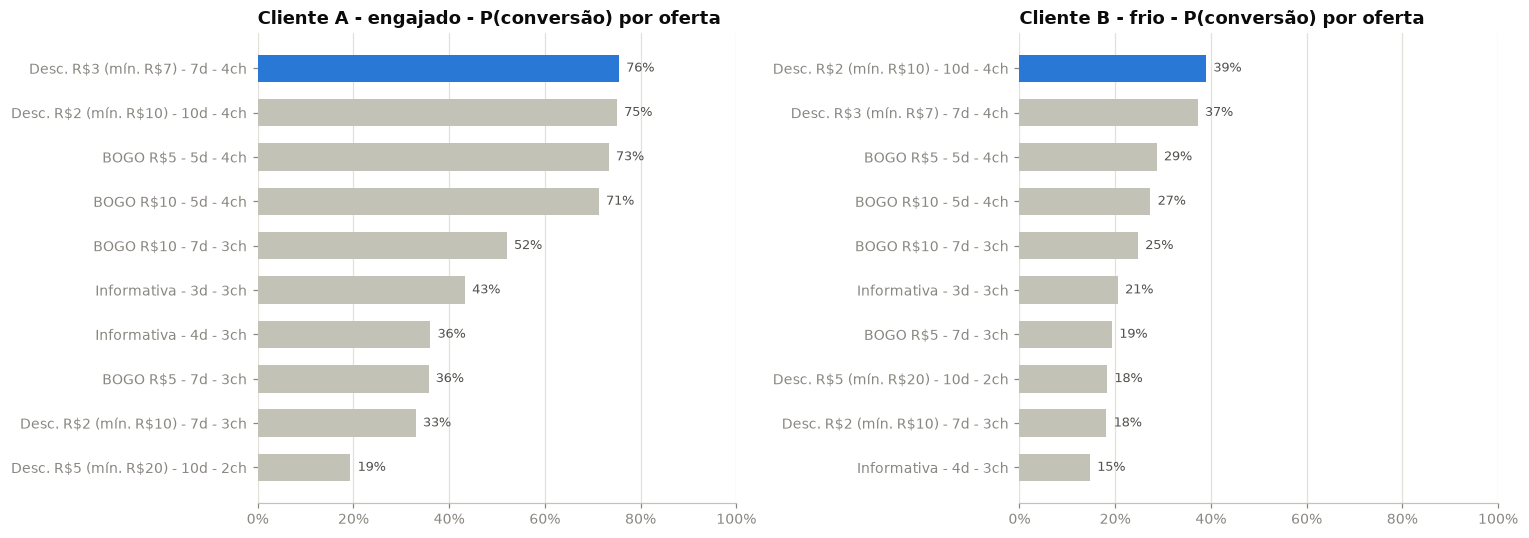

Cliente A - engajado -> recomendação: Desc. R$3 (mín. R$7) - 7d - 4ch (P = 76%)
Cliente B - frio -> recomendação: Desc. R$2 (mín. R$10) - 10d - 4ch (P = 39%)


In [18]:
def escolhe_cliente(filtro):
    # seleção determinística: ordena por receipt_id e pega o primeiro que atende ao filtro
    sel = test_states.query(filtro).sort_values("receipt_id")
    return sel.iloc[0] if len(sel) else None


# Cliente A - engajado: compra muito, comprou ontem e costuma visualizar as ofertas
cliente_a = escolhe_cliente(
    "hist_n_tx >= 8 and days_since_last_tx <= 1 and hist_view_rate >= 0.75"
)
if cliente_a is None:  # fallback: relaxa o corte
    cliente_a = escolhe_cliente("hist_n_tx >= 5 and days_since_last_tx <= 2")

# Cliente B - frio: nunca comprou, apesar de já ter recebido ofertas
cliente_b = escolhe_cliente("hist_n_tx == 0 and hist_n_received >= 2")
if cliente_b is None:
    cliente_b = escolhe_cliente("hist_n_tx == 0")

clientes = [(cliente_a, "Cliente A - engajado"), (cliente_b, "Cliente B - frio")]


def descreve(row, nome):
    rec = (
        "nunca comprou"
        if pd.isna(row["days_since_last_tx"])
        else f"última compra há {row['days_since_last_tx']:.1f} dia(s)"
    )
    view = "-" if pd.isna(row["hist_view_rate"]) else f"{row['hist_view_rate']:.0%}"
    print(
        f"{nome}: {int(row['hist_n_tx'])} compras (R$ {row['hist_spend']:.2f}) | {rec} | "
        f"viu {view} das ofertas recebidas | cliente há {int(row['membership_days'])} dias"
    )


for row, nome in clientes:
    descreve(row, nome)

# as 10 probabilidades de cada cliente, já calculadas pelo modelo na seção 5
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (row, nome) in zip(axes, clientes):
    ranking = (
        grid.loc[grid["receipt_id"] == row["receipt_id"], ["offer_id", "p_convert"]]
        .assign(label=lambda d: d["offer_id"].map(label_map))
        .sort_values("p_convert")
    )
    cores = ["#c3c2b7"] * len(ranking)
    cores[-1] = SERIES[0]  # destaque apenas na oferta recomendada (maior propensão)
    ax.barh(ranking["label"], ranking["p_convert"], color=cores, height=0.62)
    for yv, v in enumerate(ranking["p_convert"]):
        ax.text(v + 0.015, yv, f"{v:.0%}", va="center", fontsize=8.5, color="#52514e")
    ax.set_xlim(0, 1)  # mesma escala nos dois painéis: os NÍVEIS também comparam
    ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    ax.set_title(f"{nome} - P(conversão) por oferta")
    ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

for row, nome in clientes:
    top = (
        grid.loc[grid["receipt_id"] == row["receipt_id"]]
        .nlargest(1, "p_convert")
        .iloc[0]
    )
    print(
        f"{nome} -> recomendação: {label_map[top['offer_id']]} (P = {top['p_convert']:.0%})"
    )

**Como ler:**

- Os **níveis** são muito diferentes: para o cliente engajado, quase qualquer oferta tem chance
  alta; para o cliente frio, todas são baixas. Como as probabilidades são calibradas (seção 4.1),
  esses números podem ser lidos como chance real - e alimentam contas de verba e retorno.
- O **ranking** entre as ofertas não é fixo: ele muda conforme o perfil, porque o modelo aprendeu
  interações entre características do cliente e da oferta (duração, gasto mínimo, canais).
- É exatamente este cálculo que rodaria em produção para toda a base: 17 mil clientes x 10
  ofertas = 170 mil probabilidades, e cada cliente recebe a oferta do topo do seu próprio ranking.